### Programming for Biomedical Informatics
#### Week 3 - Data Integration & Summary Analysis

Using some of the skills we've developed working with eUtils we're now going to take two different lists of genes that use different identifiers convert them to NCBI Gene IDs and then use these to merge the data together. With the final merged data we will do some calculations and plots.

In [2]:
# Preliminaries
from Bio import Entrez
import urllib.request
import json
import xml.etree.ElementTree as ET

# load my API key from the file
with open('../../api_keys/ncbi.txt', 'r') as file:
    api_key = file.read().strip()

with open('../../api_keys/ncbi_email.txt', 'r') as file:
    email = file.read().strip()

Entrez.api_key = api_key
Entrez.email = email

In [3]:
# Step 1 - Load the two lists that we cannot currenly combine

'''The first file contains a list of gene symbols

e.g.
GeneSymbol
ADAM10
ADAM17
APP
NAE1
APBB1
GAPDH
BACE1

The second file contains a list of RefSeq transcripts (mRNA), and their associated GO terms:

e.g.
RefSeqID        GOTerm  Description
NM_001320570    GO:0003824      catalytic activity
NM_001320570    GO:0016787      hydrolase activity
NM_001320570    GO:0140096      catalytic activity, acting on a protein
NM_001320570    GO:0043226      organelle
NM_001320570    GO:0005634      nucleus
NM_001320570    GO:0005794      Golgi apparatus

We are going to convert Gene Symbols and Refseq IDs to NCBI Gene IDs, and then combine the two lists into a single table.
'''

# Load the gene symbols as a pandas dataframe
'''### YOUR CODE HERE ###'''
import pandas as pd

gene_symbols = pd.read_csv('GeneSymbols.tsv', sep='\t')

# Load the RefSeq data as a pandas dataframe
refseq_data = pd.read_csv('transcript_functions.tsv', sep='\t')


In [4]:
# view the first few rows of each dataframe
'''### YOUR CODE HERE ###'''
print(gene_symbols.head())
print(refseq_data.head())

  GeneSymbol
0     ADAM10
1     ADAM17
2        APP
3       NAE1
4      APBB1
       RefSeqID      GOTerm                              Description
0  NM_001320570  GO:0003824                       catalytic activity
1  NM_001320570  GO:0016787                       hydrolase activity
2  NM_001320570  GO:0140096  catalytic activity, acting on a protein
3  NM_001320570  GO:0043226                                organelle
4  NM_001320570  GO:0005634                                  nucleus


In [5]:
#Step 2 - Convert Gene Symbols to NCBI Gene IDs

# create a dictionary that maps gene symbols to gene IDs
'''### YOUR CODE HERE ###'''
symbol_to_geneid = {}

# use eSearch to convert gene symbols to NCBI Gene IDs (for the first 10 gene symbols)
# remembering to add API key and email
# remembering to use the [Gene] field in the search
# remembering to specify human
for symbol in gene_symbols['GeneSymbol'][:10]:
    handle = Entrez.esearch(db='gene', term=f"{symbol}[Gene] AND human[Organism]", retmode='xml')
    record = Entrez.read(handle)
    if record['IdList']:
        symbol_to_geneid[symbol] = record['IdList'][0]
    print(f"Processed {symbol}: {symbol_to_geneid.get(symbol, 'Not found')}")

# show the progress by printing the gene symbol and gene ID and the number of gene symbols processed so far
# This takes about 3 minutes (NB not the quickest way!)
'''### YOUR CODE HERE ###'''

#user PrettyTable to display the results
'''### YOUR CODE HERE ###'''
from prettytable import PrettyTable
table = PrettyTable()
table.field_names = ["Gene Symbol", "NCBI Gene ID"]
for symbol, geneid in symbol_to_geneid.items():
    table.add_row([symbol, geneid])
print(table)

Processed ADAM10: 102
Processed ADAM17: 6868
Processed APP: 351
Processed NAE1: 8883
Processed APBB1: 322
Processed GAPDH: 2597
Processed BACE1: 23621
Processed BACE2: 25825
Processed RTN3: 10313
Processed RTN4: 57142
+-------------+--------------+
| Gene Symbol | NCBI Gene ID |
+-------------+--------------+
|    ADAM10   |     102      |
|    ADAM17   |     6868     |
|     APP     |     351      |
|     NAE1    |     8883     |
|    APBB1    |     322      |
|    GAPDH    |     2597     |
|    BACE1    |    23621     |
|    BACE2    |    25825     |
|     RTN3    |    10313     |
|     RTN4    |    57142     |
+-------------+--------------+


In [14]:
# Step 3 - Convert RefSeq IDs to NCBI Gene IDs

# create a dictionary that maps RefSeq IDs to Gene IDs
'''### YOUR CODE HERE ###'''
refseq_to_geneid = {}

# use eSearch to convert RefSeq IDs to NCBI Gene IDs (for the first 10 RefSeq IDs)
# remembering to add API key and email
# remembering to use the [Gene] field in the search
# remembering to specify human
unique_refseqs = refseq_data['RefSeqID'].dropna().unique()[:10]
for refseq_id in unique_refseqs:
    handle = Entrez.esearch(db='nuccore', term=f"{refseq_id}[Accession] AND human[Organism]", retmode='xml')
    record = Entrez.read(handle)
    idlist = record.get('IdList', [])
    if not idlist:
        print(f"No nuccore ID found for {refseq_id}")
        continue
    with Entrez.elink(dbfrom='nuccore', db='gene', id=idlist, retmode='xml') as link_handle:
        link_record = Entrez.read(link_handle)
        gene_links = link_record[0].get('LinkSetDb', [])
        gene_ids = {
            link["Id"]
            for ls in gene_links
            for ldb in ls.get("LinkSetDb", [])
            if ldb.get("DbTo") == "gene"
            for link in ldb.get("Link", [])
        }
        if gene_ids:
            refseq_to_geneid[refseq_id] = list(gene_ids)[0]
    print(f"Processed {refseq_id}: {refseq_to_geneid.get(refseq_id, 'Not found')}")


# Search for the gene information using the RefSeq transcript ID
'''### YOUR CODE HERE ###'''
    

# for the first unique 10 values in the refseq dataframe, get the gene ID
# show the progress by printing the refseq ID and gene ID and the number of refseq IDs processed so far
'''### YOUR CODE HERE ###'''
for i, (refseq_id, geneid) in enumerate(refseq_to_geneid.items()):
    print(f"{i+1}. RefSeq ID: {refseq_id}, Gene ID: {geneid}")

IncompleteRead: IncompleteRead(167 bytes read)

In [8]:
#user PrettyTable to display the results
'''### YOUR CODE HERE ###'''
from prettytable import PrettyTable
table = PrettyTable()
table.field_names = ["RefSeq ID", "NCBI Gene ID"]
for refseq_id, geneid in refseq_to_geneid.items():
    table.add_row([refseq_id, geneid])
print(table)

+--------------+--------------+
|  RefSeq ID   | NCBI Gene ID |
+--------------+--------------+
| NM_001320570 |     102      |
|  NM_001110   |     102      |
|  NM_003183   |     6868     |
| NM_001382777 |     6868     |
| NM_001382778 |     6868     |
|  NM_175573   |    11047     |
|  NM_007002   |    11047     |
| NM_001281438 |    11047     |
| NM_001281437 |    11047     |
| NM_001206932 |     177      |
+--------------+--------------+


In [ ]:
# Step 4  - merge the refseq_to_gene_id dictionary with the refseq dataframe

# create a new column in the refseq dataframe called 'GeneID'
# fill the column with the gene IDs from the refseq_to_gene_id dictionary
'''### YOUR CODE HERE ###'''
refseq_data['GeneID'] = refseq_data['RefSeqID'].map(refseq_to_geneid)

# remove rows with missing values
'''### YOUR CODE HERE ###'''
refseq_data = refseq_data.dropna(subset=['GeneID'])

# display the refseq dataframe
'''### YOUR CODE HERE ###'''
print(refseq_data)

In [ ]:
#Step 7 - combine the gene_symbol and refseq dataframes

# convert the gene_symbol_to_id dictionary to a dataframe
'''### YOUR CODE HERE ###'''
gene_symbol_to_id_df = pd.DataFrame(list(symbol_to_geneid.items()), columns=['GeneSymbol', 'GeneID'])

# merge the refseq and gene_symbol_to_id_df dataframes on the 'GeneID' column
'''### YOUR CODE HERE ###'''
combined_df = pd.merge(refseq_data, gene_symbol_to_id_df, on='GeneID', how='inner')

# drop the GeneID column
'''### YOUR CODE HERE ###'''
combined_df = combined_df.drop(columns=['GeneID'])

# display the combined dataframe
'''### YOUR CODE HERE ###'''
print(combined_df)

Combined dataframe shape: (92, 4)
Number of unique genes: 2
Number of unique GO terms: 30


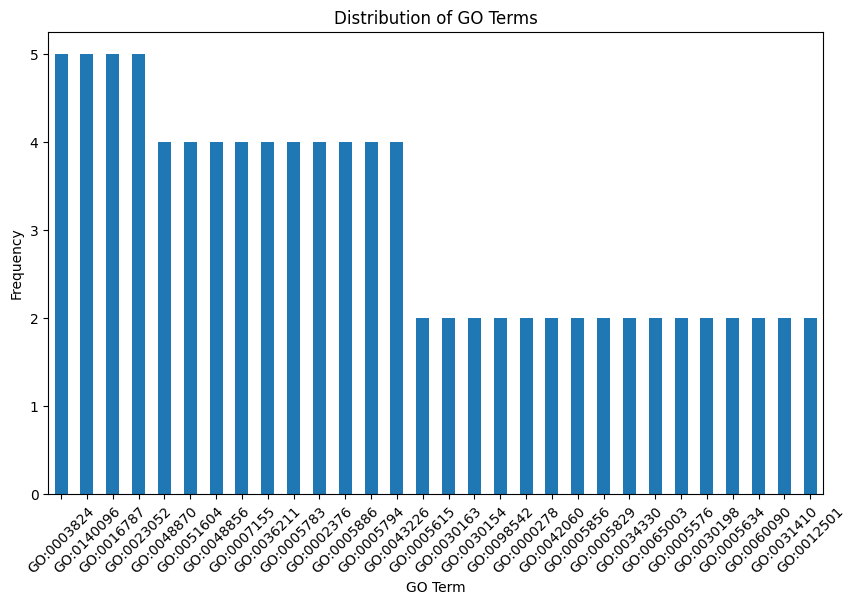

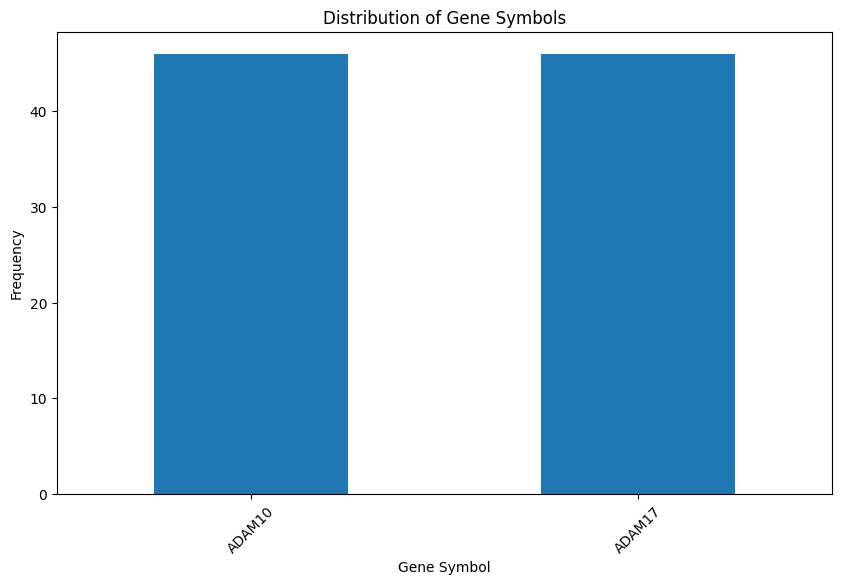

In [13]:
#Step 8 - Do some basic summary analysis

# display the number of rows and columns in the combined dataframe
'''### YOUR CODE HERE ###'''
print(f"Combined dataframe shape: {combined_df.shape}")

# count how many unique genes are in the combined dataframe
'''### YOUR CODE HERE ###'''
num_unique_genes = combined_df['GeneSymbol'].nunique()

# count how many unique GO terms are in the combined dataframe
'''### YOUR CODE HERE ###'''
num_unique_go_terms = combined_df['GOTerm'].nunique()

# display the number of unique genes and GO terms
'''### YOUR CODE HERE ###'''
print(f"Number of unique genes: {num_unique_genes}")
print(f"Number of unique GO terms: {num_unique_go_terms}")

# use some plots to visualise the data (up to you!)
'''### YOUR CODE HERE ###'''
import matplotlib.pyplot as plt

# Plot the distribution of unique GO terms
plt.figure(figsize=(10, 6))
combined_df['GOTerm'].value_counts().plot(kind='bar')
plt.title('Distribution of GO Terms')
plt.xlabel('GO Term')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Plot the distribution of unique Gene Symbols
plt.figure(figsize=(10, 6))
combined_df['GeneSymbol'].value_counts().plot(kind='bar')
plt.title('Distribution of Gene Symbols')
plt.xlabel('Gene Symbol')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()